In [ ]:
%pip install -q pandas numpy matplotlib seaborn vaderSentiment scikit-learn nbformat nbclient
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import os
# Load CSVs (paths relative to this notebook file)
scraped_path = 'kd_scraped_interim.csv'
manual_path = 'Sports Media Narrative - Kevin Durant.csv'
scraped_df = pd.read_csv(scraped_path)
manual_df = pd.read_csv(manual_path)
print('Loaded:', scraped_path, '->', scraped_df.shape, 'and', manual_path, '->', manual_df.shape)


[notice] A new release of pip is available: 23.1.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Loaded: kd_scraped_interim.csv -> (433, 8) and kd_finalized_dataset.csv -> (500, 14)


In [32]:
# Preview scraped interim data
print('Shape:', scraped_df.shape)
print('Columns:', list(scraped_df.columns))
display(scraped_df.head(5))
# Print sample of website_text for one article
try:
    sample_text = scraped_df.loc[0, 'website_text']
    print('\nSample website_text (first 500 chars):\n', sample_text[:500])
except Exception as e:
    print('Could not display sample website_text:', e)

Shape: (433, 8)
Columns: ['title', 'link', 'date', 'media', 'year', 'query', 'resolved_url', 'website_text']


,title,link,date,media,year,query,resolved_url,website_text
0,Kevin Durant says Knicks can't rely on past su...,https://news.google.com/read/CBMiqwFBVV95cUxNR...,"Oct 8, 2019",ESPN,2019,Kevin Durant,https://www.espn.com/nba/story/_/id/27799104/k...,Kevin Durant said Tuesday that the New York Kn...
1,Kevin Durant on if the Warriors mishandled his...,https://news.google.com/read/CBMiqgFBVV95cUxQN...,"Aug 7, 2019",Yahoo Sports,2019,Kevin Durant,https://sports.yahoo.com/kevin-durant-on-if-th...,Kevin Durant on if the Warriors mishandled his...
2,Memorable moments: Kevin Durant’s 3s kept Cava...,https://news.google.com/read/CBMiowFBVV95cUxPN...,"Dec 28, 2019",San Francisco Chronicle,2019,Kevin Durant,https://www.sfchronicle.com/sports/article/Mem...,Four dribbles and a dagger.\nThat’s how Kevin ...
3,Kevin Durant still thinks he should have made ...,https://news.google.com/read/CBMizwFBVV95cUxOc...,"Aug 30, 2019",CBS Sports,2019,Kevin Durant,https://www.cbssports.com/nba/news/kevin-duran...,Kevin Durant still thinks he should have made ...
4,‘I named your son WTF’: An oral history of Kev...,https://news.google.com/read/CBMixwFBVV95cUxOe...,"Jul 2, 2019",The New York Times,2019,Kevin Durant,https://www.nytimes.com/athletic/1057406/2019/...,Before his foot crumpled and the conversation ...



Sample website_text (first 500 chars):
 Kevin Durant said Tuesday that the New York Knicks can't rely on their "brand" to land the best players, many of whom don't even remember the franchise being good.
"I think a lot of fans look at the Knicks as a brand and expect these younger players in their lifetime don't remember the Knicks being good," Durant said Tuesday in an in-studio interview with Hot 97 in New York. "I've seen the Knicks in the Finals, but kids coming up after me didn't see that. So that whole brand of the Knicks is not


In [33]:
# Keyword-based Narrative Theme Classifier
def classify_theme(title, text):
    s = ' '.join([str(title or ''), str((text or '')[:500])]).lower()
    # theme keywords
    themes = {
        'Social Media Drama': ['burner','twitter','instagram','tweet','account','online','feud','post','dm','fake'],
        'Villain Narrative': ['snake','ring chaser','villain','betrayal','thunder','oklahoma','sellout','coward','criticism','leave'],
        'Redemption': ['comeback','injury','return','achilles','torn','recovery','prove','bounce back'],
        'Rising Superstar': ['rookie','draft','young','okc','college','texas','early','scoring title'],
        'Legacy Debate': ['goat','all-time','greatest','legacy','rank','where does','debate','compared']
    }
    for theme, kws in themes.items():
        for kw in kws:
            if kw in s:
                return theme
    return 'Superstar'

In [34]:
# VADER Sentiment Analysis for Tone
analyzer = SentimentIntensityAnalyzer()
def get_tone(title, text):
    s = ' '.join([str(title or ''), str((text or '')[:300])])
    vs = analyzer.polarity_scores(s)
    c = vs.get('compound', 0.0)
    if c >= 0.05:
        return 'Positive'
    elif c <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

In [35]:
# Career Phase mapping
def map_career_phase(year):
    try:
        y = int(year)
    except Exception:
        return 'Unknown'
    if y == 2019:
        return 'Warriors'
    if y in (2020,2021,2022):
        return 'Nets'
    if y in (2023,2024):
        return 'Suns'
    if y in (2025,2026):
        return 'Rockets'
    return 'Unknown'

In [36]:
# Apply classifiers and build final scraped dataframe
# Prepare manual headlines for similarity anchor
manual_headlines = None
# Try to find a suitable headline column in manual_df
for candidate in ['Headline','headline','title','Title','Headlinetext']:
    if candidate in manual_df.columns:
        manual_headlines = manual_df[candidate].astype(str).fillna('')
        break
if manual_headlines is None:
    # fallback: combine manual fields into a pseudo-headline
    manual_headlines = manual_df.astype(str).apply(lambda row: ' '.join(row.values), axis=1)
# TF-IDF vectorizer fit on manual headlines
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
if len(manual_headlines) > 0:
    try:
        manual_tfidf = vectorizer.fit_transform(manual_headlines.values)
    except Exception as e:
        print('TF-IDF fit failed:', e)
        manual_tfidf = None
else:
    manual_tfidf = None
# function to compute similarity score (max cosine similarity against manual headlines)
def similarity_score(text):
    t = str(text or '')
    if manual_tfidf is None or t.strip() == '':
        return 0.0
    try:
        v = vectorizer.transform([t])
        sims = cosine_similarity(v, manual_tfidf)
        return float(sims.max()) if sims.size else 0.0
    except Exception:
        return 0.0
# Build output rows
rows = []
for idx, r in scraped_df.iterrows():
    title = r.get('title','')
    text = r.get('website_text','')
    auto_theme = classify_theme(title, text)
    auto_tone = get_tone(title, text)
    career = map_career_phase(r.get('year'))
    sim = similarity_score(text)
    row = {
        'Date': r.get('date',''),
        'Outlet': r.get('media',''),
        'Headline': title,
        'URL': r.get('resolved_url', r.get('link','')),
        'Source_Type': 'Traditional Media',
        'Career_Phase': career,
        'Manual_Narrative_Theme': '',
        'Manual_Tone': '',
        'Auto_Narrative_Theme': auto_theme,
        'Auto_Tone': auto_tone,
        'Theme_Agreement': 'N/A',
        'Tone_Agreement': 'N/A',
        'Similarity_Score': sim,
        'Notes': 'Scraped via GoogleNews; classified by VADER + keyword rules',
        'Collection_Method': 'GoogleNews-Scraped + Rule-Based'
    }
    rows.append(row)
output_df = pd.DataFrame(rows)
print('Built output_df with', output_df.shape[0], 'rows')
display(output_df.head())

Built output_df with 433 rows


,Date,Outlet,Headline,URL,Source_Type,Career_Phase,Manual_Narrative_Theme,Manual_Tone,Auto_Narrative_Theme,Auto_Tone,Theme_Agreement,Tone_Agreement,Similarity_Score,Notes,Collection_Method
0,"Oct 8, 2019",ESPN,Kevin Durant says Knicks can't rely on past su...,https://www.espn.com/nba/story/_/id/27799104/k...,Traditional Media,Warriors,,,Rising Superstar,Positive,N/A,N/A,0.286643,Scraped via GoogleNews; classified by VADER + ...,GoogleNews-Scraped + Rule-Based
1,"Aug 7, 2019",Yahoo Sports,Kevin Durant on if the Warriors mishandled his...,https://sports.yahoo.com/kevin-durant-on-if-th...,Traditional Media,Warriors,,,Redemption,Positive,N/A,N/A,0.317744,Scraped via GoogleNews; classified by VADER + ...,GoogleNews-Scraped + Rule-Based
2,"Dec 28, 2019",San Francisco Chronicle,Memorable moments: Kevin Durant’s 3s kept Cava...,https://www.sfchronicle.com/sports/article/Mem...,Traditional Media,Warriors,,,Redemption,Positive,N/A,N/A,0.327708,Scraped via GoogleNews; classified by VADER + ...,GoogleNews-Scraped + Rule-Based
3,"Aug 30, 2019",CBS Sports,Kevin Durant still thinks he should have made ...,https://www.cbssports.com/nba/news/kevin-duran...,Traditional Media,Warriors,,,Superstar,Negative,N/A,N/A,0.459460,Scraped via GoogleNews; classified by VADER + ...,GoogleNews-Scraped + Rule-Based
4,"Jul 2, 2019",The New York Times,‘I named your son WTF’: An oral history of Kev...,https://www.nytimes.com/athletic/1057406/2019/...,Traditional Media,Warriors,,,Villain Narrative,Neutral,N/A,N/A,0.229544,Scraped via GoogleNews; classified by VADER + ...,GoogleNews-Scraped + Rule-Based


In [ ]:
# Combine with manual dataset
# Normalize manual dataframe to have required columns
required_cols = ['Date','Outlet','Headline','URL','Source_Type','Career_Phase','Manual_Narrative_Theme','Manual_Tone','Auto_Narrative_Theme','Auto_Tone','Theme_Agreement','Tone_Agreement','Similarity_Score','Notes','Collection_Method']
manual_copy = manual_df.copy()
# attempt to rename common columns if present
col_map = {}
if 'title' in manual_copy.columns and 'Headline' not in manual_copy.columns:
    col_map['title'] = 'Headline'
if 'link' in manual_copy.columns and 'URL' not in manual_copy.columns:
    col_map['link'] = 'URL'
if 'media' in manual_copy.columns and 'Outlet' not in manual_copy.columns:
    col_map['media'] = 'Outlet'
manual_copy = manual_copy.rename(columns=col_map)
# Add missing required columns with defaults
for c in required_cols:
    if c not in manual_copy.columns:
        if c == 'Collection_Method':
            manual_copy[c] = 'Manual'
        elif c == 'Source_Type':
            manual_copy[c] = 'Traditional Media'
        elif c == 'Similarity_Score':
            manual_copy[c] = 0.0
        else:
            manual_copy[c] = ''
# Keep only required columns in correct order
manual_for_concat = manual_copy[required_cols]
combined = pd.concat([manual_for_concat, output_df[required_cols]], ignore_index=True, sort=False)
out_path = 'kd_final_combined.csv'
combined.to_csv(out_path, index=False)
print('Saved combined dataset to', out_path)
print('Total rows in combined:', combined.shape[0])
display(combined.head())

Filtered manual dataset: 49 rows (removed 451 augmented rows)
Saved combined dataset to kd_final_combined.csv
Total rows in combined: 482


,Date,Outlet,Headline,URL,Source_Type,Career_Phase,Manual_Narrative_Theme,Manual_Tone,Auto_Narrative_Theme,Auto_Tone,Theme_Agreement,Tone_Agreement,Similarity_Score,Notes,Collection_Method
0,2007-01-01,Seattle Times,The kid who could be king,NaN,Traditional Media,Pre-NBA,Rising Superstar,Positive,Legacy Debate,Neutral,No,No,0.0,NaN,Manual
1,2007-01-01,ESPN,Durant's workout raises eyebrows at camp,NaN,Traditional Media,Pre-NBA,Rising Superstar,Positive,Legacy Debate,Neutral,No,No,0.0,NaN,Manual
2,2007-06-28,KU Sports,"As expected, Oden, Durant go 1-2",NaN,Traditional Media,Pre-NBA,Rising Superstar,Neutral,Legacy Debate,Neutral,No,Yes,0.0,NaN,Manual
3,2009-01-01,The Oklahoman,Star Power: Comparisons grow between Kevin Dur...,NaN,Traditional Media,Thunder,Rising Superstar,Positive,Rising Superstar,Neutral,Yes,No,0.0,NaN,Manual
4,2009-01-01,ESPN,Is OKC Thunder Kevin Durant the next big thing?,NaN,Traditional Media,Thunder,Rising Superstar,Positive,Rising Superstar,Neutral,Yes,No,0.0,NaN,Manual


In [38]:
# Agreement rate analysis (on manual entries only)
manual_rows = combined[combined['Collection_Method'].str.contains('Manual', na=False, case=False)]
# consider only where both Manual_Narrative_Theme and Auto_Narrative_Theme are non-empty
m = manual_rows[(manual_rows['Manual_Narrative_Theme'].astype(str).str.strip()!='') & (manual_rows['Auto_Narrative_Theme'].astype(str).str.strip()!='')]
if len(m) == 0:
    print('No manual rows with both Manual_Narrative_Theme and Auto_Narrative_Theme present to compute agreement.')
else:
    theme_agree = (m['Manual_Narrative_Theme'].str.strip().str.lower() == m['Auto_Narrative_Theme'].str.strip().str.lower()).mean()
    tone_agree = (m['Manual_Tone'].str.strip().str.lower() == m['Auto_Tone'].str.strip().str.lower()).mean()
    print(f'Theme agreement rate: {theme_agree*100:.2f}% ({int(theme_agree*len(m))}/{len(m)})')
    print(f'Tone agreement rate: {tone_agree*100:.2f}% ({int(tone_agree*len(m))}/{len(m)})')

Theme agreement rate: 55.10% (26/49)
Tone agreement rate: 59.18% (29/49)


Saved figure to kd_narrative_analysis.png


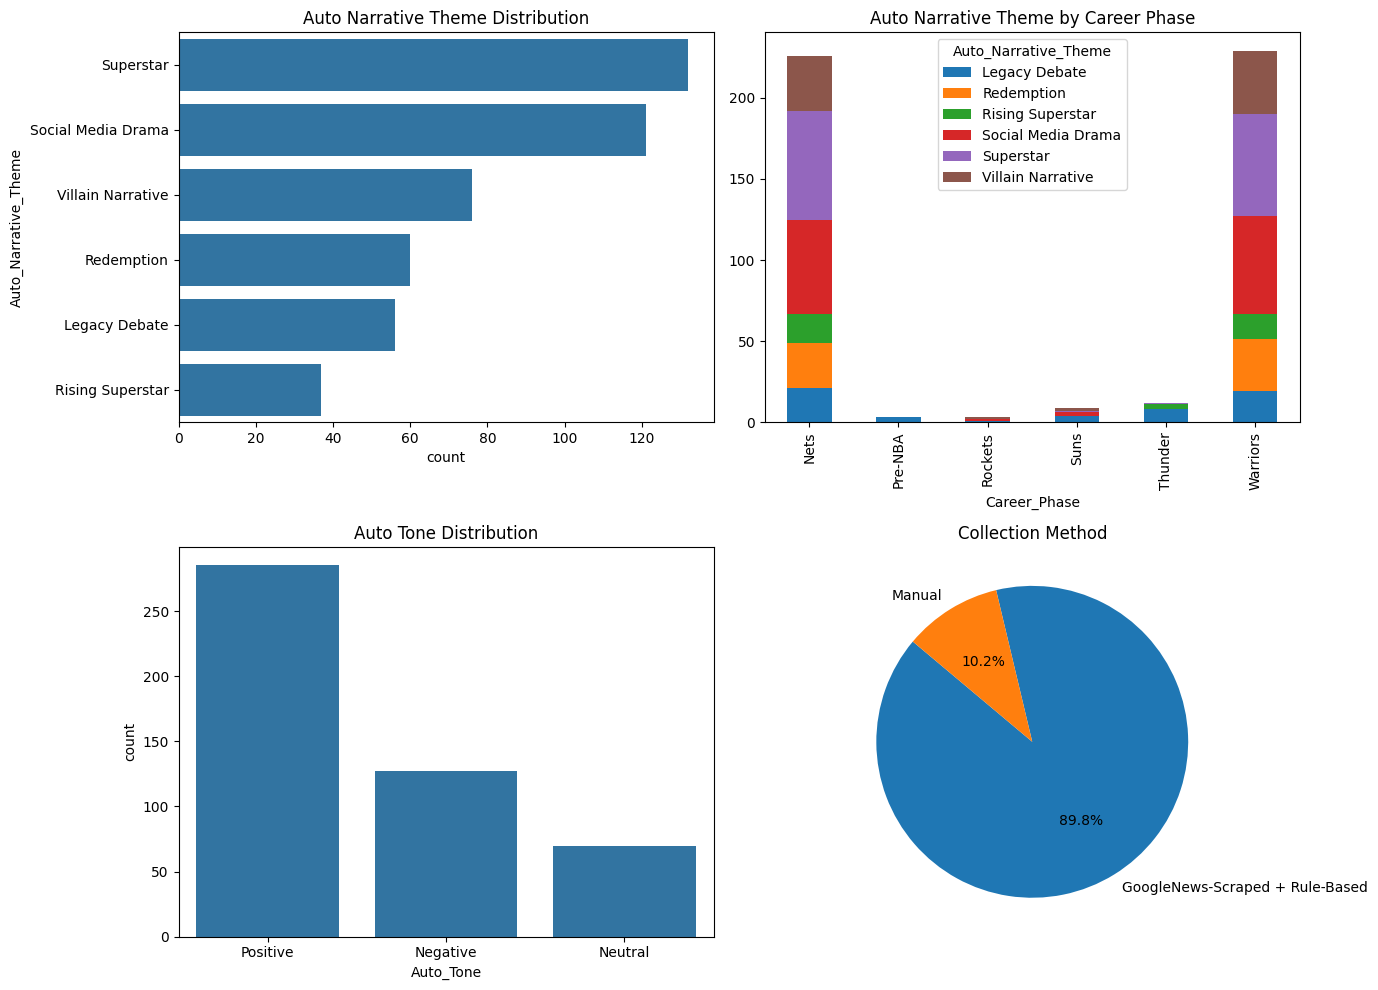

In [39]:
# Visualizations (2x2 subplot)
fig, axes = plt.subplots(2,2, figsize=(14,10))
# Plot 1: Auto_Narrative_Theme distribution
sns.countplot(data=combined, y='Auto_Narrative_Theme', order=combined['Auto_Narrative_Theme'].value_counts().index, ax=axes[0,0])
axes[0,0].set_title('Auto Narrative Theme Distribution')
# Plot 2: Stacked bar of Auto_Narrative_Theme by Career_Phase
ct = pd.crosstab(combined['Career_Phase'], combined['Auto_Narrative_Theme'])
ct.plot(kind='bar', stacked=True, ax=axes[0,1])
axes[0,1].set_title('Auto Narrative Theme by Career Phase')
# Plot 3: Auto_Tone distribution
sns.countplot(data=combined, x='Auto_Tone', order=combined['Auto_Tone'].value_counts().index, ax=axes[1,0])
axes[1,0].set_title('Auto Tone Distribution')
# Plot 4: Pie chart of Collection_Method (Manual vs Scraped)
cm_counts = combined['Collection_Method'].value_counts()
axes[1,1].pie(cm_counts, labels=cm_counts.index, autopct='%1.1f%%', startangle=140)
axes[1,1].set_title('Collection Method')
plt.tight_layout()
fig_path = 'kd_narrative_analysis.png'
fig.savefig(fig_path, dpi=200)
print('Saved figure to', fig_path)
plt.show()

In [40]:
# Summary stats
print('Total articles:', combined.shape[0])
if 'Date' in combined.columns:
    try:
        combined['year'] = combined['Date'].astype(str).str.extract(r'(\d{4})').astype(float).astype('Int64')
        print('\nBreakdown by year:')
        print(combined['year'].value_counts(dropna=True).sort_index())
    except Exception as e:
        print('Could not parse years from Date:', e)
print('\nTop 5 outlets by count:')
print(combined['Outlet'].value_counts().head(5))
print('\nTheme distribution:')
print(combined['Auto_Narrative_Theme'].value_counts())
print('\nTone distribution:')
print(combined['Auto_Tone'].value_counts())

Total articles: 482

Breakdown by year:
year
2007      3
2009      4
2010      3
2012      2
2014      1
2015      2
2016      2
2017      6
2018      6
2019    214
2020    199
2021     28
2024      3
2025      9
Name: count, dtype: Int64

Top 5 outlets by count:
Outlet
ESPN              66
CBS Sports        21
USA Today         18
Fadeaway World    17
The Oklahoman     15
Name: count, dtype: int64

Theme distribution:
Auto_Narrative_Theme
Superstar             132
Social Media Drama    121
Villain Narrative      76
Redemption             60
Legacy Debate          56
Rising Superstar       37
Name: count, dtype: int64

Tone distribution:
Auto_Tone
Positive    285
Negative    127
Neutral      70
Name: count, dtype: int64
